# STATISTIC ANALYSIS OF EXOPLANET TERMINATOR AND TRANSIT PHASES ASYMMETRY

    In this code below a project explicitly defined in files "Projekat_za_Nacionalnu Konferenciju_Astrostat" and "TRANSIT_WASP17B" is being done and analysed. In this Jupyter notebook version, everything is defined and done in first cell in meaning of creating spectral input for the rest of the code and analysis - per levels of asymmetries three transit phases (egress, mid-transit and egress), i. e. that part is now automatic as to eliminate human error in working with files. It saves those data in .txt files, and remaining metrics in .csv files. We started from ultra asymmetry as first model and configurational file that it uses for (which is the most extreme asymmetry, cloudfractions are 0, 50 and 100%, and same principle apllies to atmosphere temperatures), In future, a greater parameter grid will be added (other aerosols, etc).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from IPython.display import display, HTML
import shutil
import requests
import re
import time

# Automatised generation of PSG spectra

This cell automatises:
- Asymmetry level varying,
- Sending `.cfg` files to NASA PSG system,
- Downloading `psg_rad.txt`,
- Renaming files pred:
  - asymmetry level,
  - Transit phase (`ingress`, `mid`, `egress`),
- Placing in aproppriate folders.

After executing this cell:
- The rest of the notebook works without change,
- Analysis, graphs and tables are generated automatically.


In [ ]:
PSG_URL = "https://psg.gsfc.nasa.gov/api.php"
cfg_templates = {
    "ingress": "Asym_1.0/wasp17b_transit_ingress_ultra_hazy_cold.cfg",
    "mid": "Asym_1.0/wasp17b_transit_mid_ultra_reference.cfg",
    "egress": "Asym_1.0/wasp17b_transit_egress_ultra_clear_hot.cfg"
}
PARAMS = [
    "ATMOSPHERE-TEMPERATURE",
    "ATMOSPHERE-CLOUDFRACTION",
    "ATMOSPHERE-AABUN",
]
# PSG CALL (HTML RESPONSE)
def run_psg(cfg_text):
    response = requests.post(
        PSG_URL,
        data=cfg_text.encode("utf-8"),
        headers={"User-Agent": "Mozilla/5.0", "Content-Type": "text/plain"}, timeout=300)
    text = response.text
    if response.status_code != 200:
        raise RuntimeError(f"PSG error: {response.status_code}")
    if "# Wave/freq" not in text:
        raise RuntimeError("PSG returned response without spectrum")
    return text
# EXTRACT SPECTRUM FROM HTML
def extract_spectrum(psg_html):
    start_patterns = ["# Wave/freq", "#Wave/freq"]
    lines = psg_html.splitlines()
    start_idx = -1
    for i, line in enumerate(lines):
        if any(p in line for p in start_patterns):
            start_idx = i
            break
    if start_idx == -1:
        raise RuntimeError("Spectrum header not found")
    data = []
    for l in lines[start_idx:]:
        l = l.strip()
        if not l:
            continue
        if l.startswith("<"):
            continue
        if l.startswith("#") and not l[0].isdigit():
            continue
        parts = l.split()
        if len(parts) < 5:
            continue
        try:
            float(parts[0])
        except:
            continue
        data.append(l)
    if "Wave/freq" not in psg_html:
        raise RuntimeError("No spectrum block in PSG output")
    from io import StringIO
    return np.loadtxt(StringIO("\n".join(data)))
def run_psg_debug(cfg_text, phase="unknown", asym="unknown"):
    response = requests.post(PSG_URL, data=cfg_text.encode("utf-8"), headers={"User-Agent": "Mozilla/5.0", "Content-Type": "text/plain"}, timeout=300)
    print(f"\nPSG DEBUG | phase={phase} | asym={asym}")
    print("STATUS:", response.status_code)
    print("CONTENT LENGTH:", len(response.text))
    text = response.text
    print("\n--- RAW FIRST 80 LINES ---\n")
    for i, line in enumerate(text.splitlines()[:80]):
        print(f"{i:03d}: {line}")
    if "# Wave/freq" in text or "#Wave/freq" in text:
        print("\n[SUCCESS] Spectrum found")
    else:
        print("\n[WARNING] No spectrum header found")
    return text
# CFG HELPERS
def get_value(cfg, tag):
    m = re.search(rf"<{tag}>([-+0-9.eE]+)", cfg)
    return float(m.group(1)) if m else None
def set_value(cfg, tag, val):
    return re.sub(rf"<{tag}>[-+0-9.eE]+", f"<{tag}>{val}", cfg)
# INTERPOLATION (mid ↔ extreme)
def interpolate(mid_cfg, ext_cfg, a):
    out = mid_cfg
    for p in PARAMS:
        mid_v = get_value(mid_cfg, p)
        ext_v = get_value(ext_cfg, p)
        if mid_v is None or ext_v is None:
            continue
        new_v = mid_v + a * (ext_v - mid_v)
        out = set_value(out, p, new_v)
    return out
# MAIN PIPELINE
def run_asymmetry_pipeline():
    # load CFGs
    with open(cfg_templates["ingress"], "r", encoding="utf-8") as f:
        cfg_ing_base = f.read()
    with open(cfg_templates["mid"], "r", encoding="utf-8") as f:
        cfg_mid = f.read()
    with open(cfg_templates["egress"], "r", encoding="utf-8") as f:
        cfg_eg_base = f.read()
    asymmetry_levels = np.arange(0.1, 1.0, 0.1)
    for a in asymmetry_levels:
        folder = f"Asym_{a:.1f}"
        os.makedirs(folder, exist_ok=True)
        print("\nASYMMETRY LEVEL:", a)
        cfg_ing = interpolate(cfg_mid, cfg_ing_base, a)
        cfg_eg  = interpolate(cfg_mid, cfg_eg_base, a)
        scenarios = {"ingress": cfg_ing, "mid": cfg_mid, "egress": cfg_eg}
        for phase, cfg in scenarios.items():
            print("Running:", phase)
            # save cfg
            cfg_path = os.path.join(folder, f"{phase}.cfg")
            with open(cfg_path, "w", encoding="utf-8") as f:
                f.write(cfg)
            # PSG CALL (production)
            html = run_psg(cfg)
            # extract spectrum
            data = extract_spectrum(html)
            # save numeric output
            out_path = os.path.join(folder, f"{phase}.txt")
            np.savetxt(out_path, data)
            print("Saved:", out_path)
    print("\nPIPELINE COMPLETE")
# RUN
run_asymmetry_pipeline()


ASYMMETRY LEVEL: 0.1
Running: ingress
Saved: Asym_0.1\ingress.txt
Running: mid
Saved: Asym_0.1\mid.txt
Running: egress
Saved: Asym_0.1\egress.txt

ASYMMETRY LEVEL: 0.2
Running: ingress
Saved: Asym_0.2\ingress.txt
Running: mid
Saved: Asym_0.2\mid.txt
Running: egress
Saved: Asym_0.2\egress.txt

ASYMMETRY LEVEL: 0.30000000000000004
Running: ingress
Saved: Asym_0.3\ingress.txt
Running: mid
Saved: Asym_0.3\mid.txt
Running: egress
Saved: Asym_0.3\egress.txt

ASYMMETRY LEVEL: 0.4
Running: ingress
Saved: Asym_0.4\ingress.txt
Running: mid
Saved: Asym_0.4\mid.txt
Running: egress
Saved: Asym_0.4\egress.txt

ASYMMETRY LEVEL: 0.5
Running: ingress
Saved: Asym_0.5\ingress.txt
Running: mid
Saved: Asym_0.5\mid.txt
Running: egress
Saved: Asym_0.5\egress.txt

ASYMMETRY LEVEL: 0.6
Running: ingress
Saved: Asym_0.6\ingress.txt
Running: mid
Saved: Asym_0.6\mid.txt
Running: egress
Saved: Asym_0.6\egress.txt

ASYMMETRY LEVEL: 0.7000000000000001
Running: ingress
Saved: Asym_0.7\ingress.txt
Running: mid
Saved: 

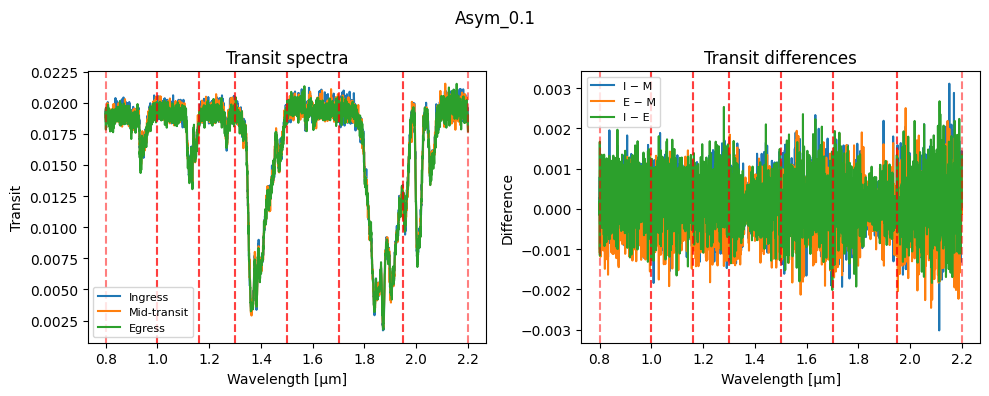

Regional metrics for Asym_0.1:


,Region,σ_det,σ_det_err,|I−E|,|I−E|_err,Z_D,ρ
0,0.8-1,0.588255,0.037156,0.000494,0.000014,5.937167,0.855094
1,1-1.16,0.531113,0.047765,0.000500,0.000018,4.349557,0.945654
2,1.16-1.3,0.487809,0.054305,0.000524,0.000021,6.196017,0.589926
3,1.3-1.5,0.279790,0.049055,0.000419,0.000017,3.296297,0.995064
4,1.5-1.7,0.380649,0.052715,0.000581,0.000023,5.816045,0.271479
5,1.7-1.95,0.240145,0.049735,0.000473,0.000018,3.142635,0.995266
6,1.95-2.2,0.259030,0.052865,0.000621,0.000026,4.020994,0.976575


Global metrics for Asym_0.1:


,Asymmetry,RMS,RMS_err,E,E_err
0,Asym_0.1,0.000648,0.000009,0.056864,0.002528


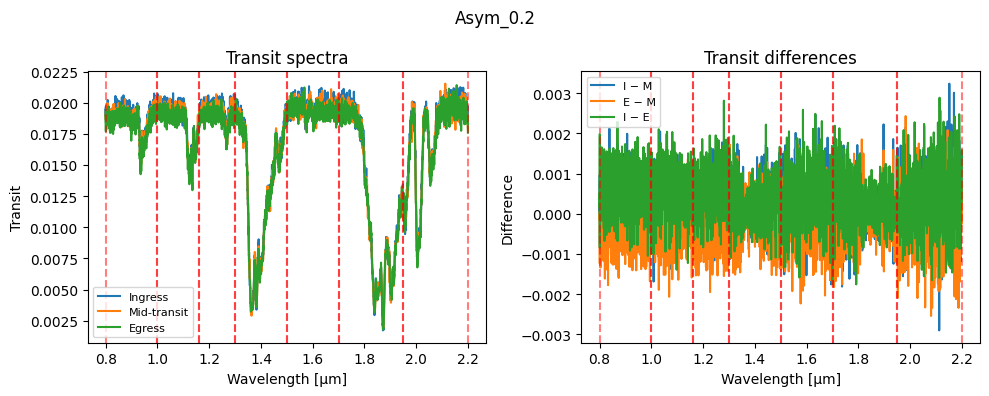

Regional metrics for Asym_0.2:


,Region,σ_det,σ_det_err,|I−E|,|I−E|_err,Z_D,ρ
0,0.8-1,1.127067,0.037156,0.000668,0.000017,5.937167,0.854451
1,1-1.16,1.017688,0.047765,0.000651,0.000021,4.349557,0.945450
2,1.16-1.3,0.932828,0.054305,0.000660,0.000025,6.196017,0.589482
3,1.3-1.5,0.530893,0.049055,0.000468,0.000018,3.296297,0.995024
4,1.5-1.7,0.725180,0.052715,0.000679,0.000025,5.816045,0.269397
5,1.7-1.95,0.453665,0.049735,0.000517,0.000020,3.142635,0.995260
6,1.95-2.2,0.488700,0.052865,0.000674,0.000027,4.020994,0.976559


Global metrics for Asym_0.2:


,Asymmetry,RMS,RMS_err,E,E_err
0,Asym_0.2,0.00077,0.00001,0.108343,0.002528


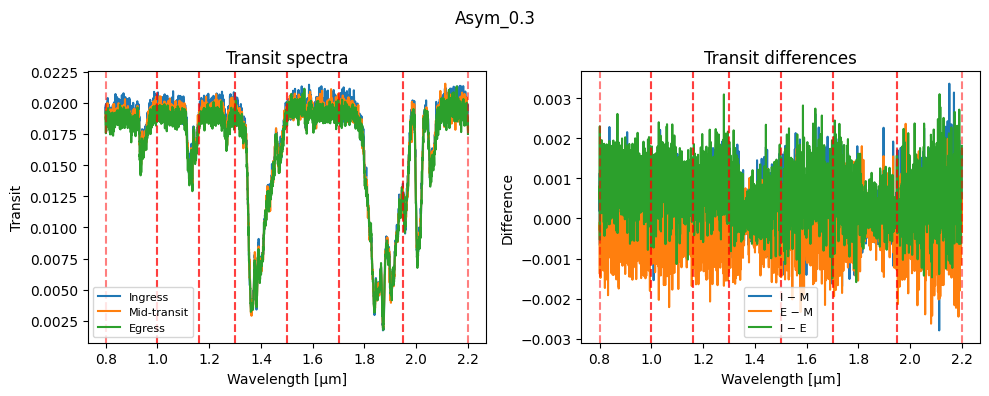

Regional metrics for Asym_0.3:


,Region,σ_det,σ_det_err,|I−E|,|I−E|_err,Z_D,ρ
0,0.8-1,1.652022,0.037157,0.000899,0.000018,5.937167,0.853213
1,1-1.16,1.491816,0.047765,0.000857,0.000024,4.349557,0.945043
2,1.16-1.3,1.366123,0.054305,0.000850,0.000028,6.196017,0.588446
3,1.3-1.5,0.773445,0.049055,0.000539,0.000020,3.296297,0.994952
4,1.5-1.7,1.059561,0.052715,0.000822,0.000029,5.816045,0.265805
5,1.7-1.95,0.659952,0.049736,0.000581,0.000022,3.142635,0.995246
6,1.95-2.2,0.709929,0.052865,0.000754,0.000029,4.020994,0.976502


Global metrics for Asym_0.3:


,Asymmetry,RMS,RMS_err,E,E_err
0,Asym_0.3,0.00093,0.00001,0.15829,0.002529


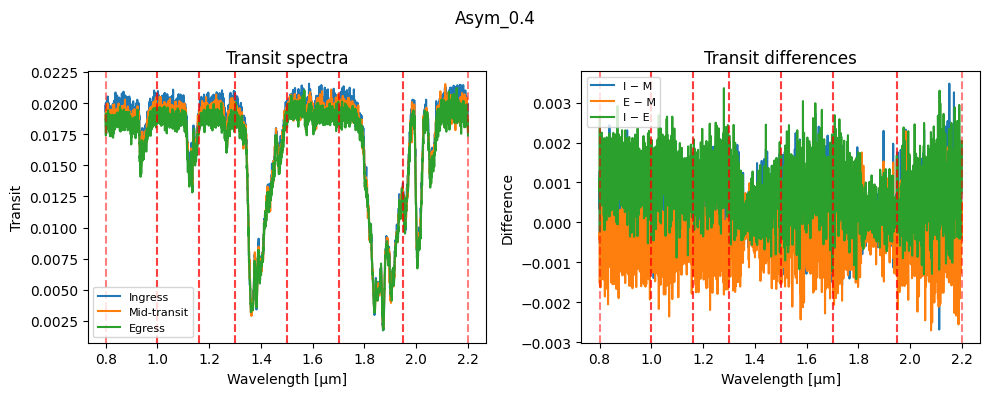

Regional metrics for Asym_0.4:


,Region,σ_det,σ_det_err,|I−E|,|I−E|_err,Z_D,ρ
0,0.8-1,2.171180,0.037157,0.001158,0.000019,5.937167,0.851416
1,1-1.16,1.960779,0.047765,0.001093,0.000025,4.349557,0.944448
2,1.16-1.3,1.794570,0.054305,0.001073,0.000030,6.196017,0.586867
3,1.3-1.5,1.012466,0.049055,0.000627,0.000021,3.296297,0.994850
4,1.5-1.7,1.389751,0.052715,0.000997,0.000032,5.816045,0.260774
5,1.7-1.95,0.863237,0.049736,0.000662,0.000023,3.142635,0.995225
6,1.95-2.2,0.927626,0.052865,0.000856,0.000032,4.020994,0.976411


Global metrics for Asym_0.4:


,Asymmetry,RMS,RMS_err,E,E_err
0,Asym_0.4,0.001111,0.00001,0.207563,0.002531


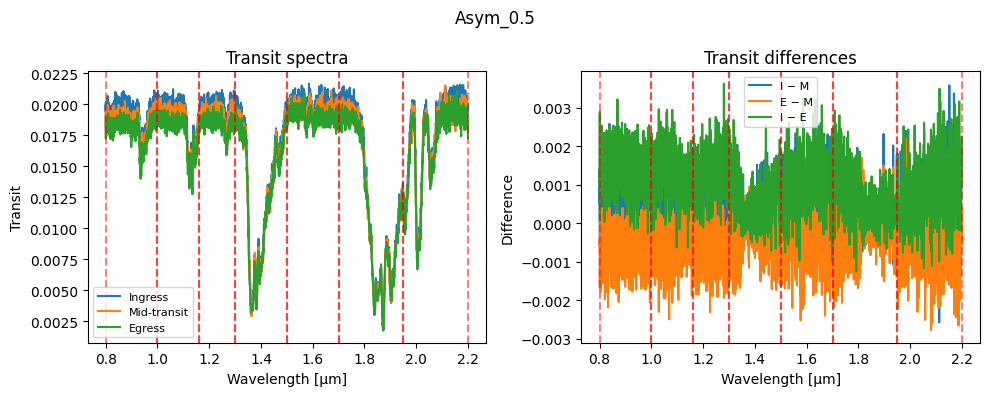

Regional metrics for Asym_0.5:


,Region,σ_det,σ_det_err,|I−E|,|I−E|_err,Z_D,ρ
0,0.8-1,2.687376,0.037157,0.001427,0.000020,5.937167,0.849071
1,1-1.16,2.427116,0.047765,0.001341,0.000026,4.349557,0.943668
2,1.16-1.3,2.220568,0.054305,0.001311,0.000031,6.196017,0.584771
3,1.3-1.5,1.249708,0.049055,0.000726,0.000022,3.296297,0.994719
4,1.5-1.7,1.717848,0.052715,0.001193,0.000034,5.816045,0.254339
5,1.7-1.95,1.065000,0.049736,0.000755,0.000025,3.142635,0.995197
6,1.95-2.2,1.143531,0.052865,0.000975,0.000034,4.020994,0.976286


Global metrics for Asym_0.5:


,Asymmetry,RMS,RMS_err,E,E_err
0,Asym_0.5,0.001305,0.000011,0.256453,0.002533


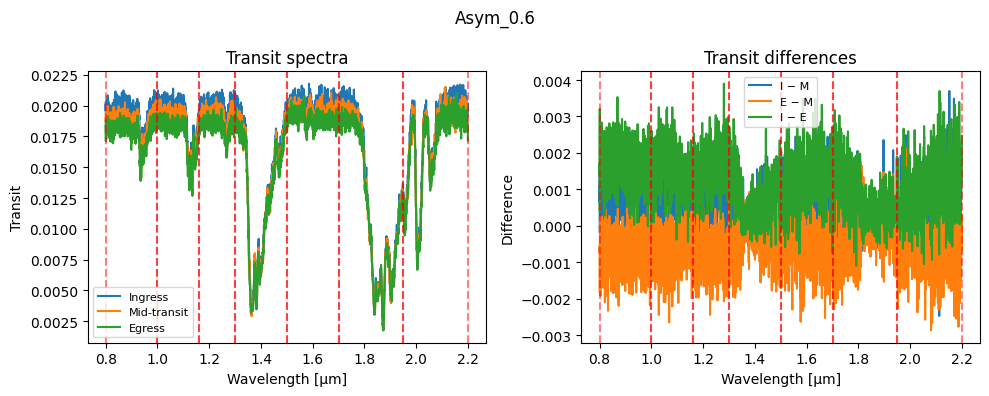

Regional metrics for Asym_0.6:


,Region,σ_det,σ_det_err,|I−E|,|I−E|_err,Z_D,ρ
0,0.8-1,3.201878,0.037157,0.001699,0.000020,5.937167,0.846182
1,1-1.16,2.891972,0.047765,0.001594,0.000026,4.349557,0.942702
2,1.16-1.3,2.645195,0.054305,0.001557,0.000032,6.196017,0.582167
3,1.3-1.5,1.485959,0.049055,0.000833,0.000023,3.296297,0.994557
4,1.5-1.7,2.044746,0.052715,0.001401,0.000035,5.816045,0.246549
5,1.7-1.95,1.265904,0.049736,0.000856,0.000026,3.142635,0.995161
6,1.95-2.2,1.358392,0.052865,0.001108,0.000035,4.020994,0.976130


Global metrics for Asym_0.6:


,Asymmetry,RMS,RMS_err,E,E_err
0,Asym_0.6,0.001505,0.000011,0.305084,0.002536


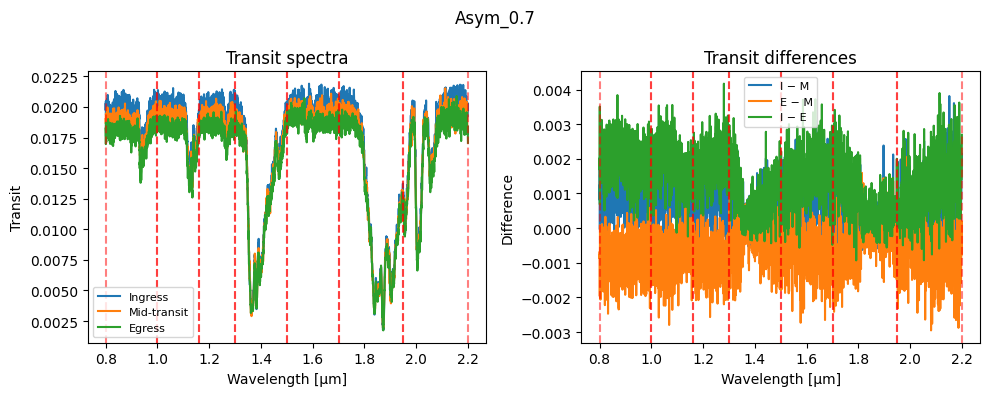

Regional metrics for Asym_0.7:


,Region,σ_det,σ_det_err,|I−E|,|I−E|_err,Z_D,ρ
0,0.8-1,3.715312,0.037157,0.001971,0.000020,5.937167,0.842750
1,1-1.16,3.355896,0.047766,0.001849,0.000026,4.349557,0.941549
2,1.16-1.3,3.068962,0.054305,0.001805,0.000032,6.196017,0.579067
3,1.3-1.5,1.721582,0.049055,0.000947,0.000024,3.296297,0.994367
4,1.5-1.7,2.370910,0.052715,0.001616,0.000035,5.816045,0.237454
5,1.7-1.95,1.466273,0.049736,0.000964,0.000027,3.142635,0.995119
6,1.95-2.2,1.572616,0.052865,0.001251,0.000037,4.020994,0.975941


Global metrics for Asym_0.7:


,Asymmetry,RMS,RMS_err,E,E_err
0,Asym_0.7,0.00171,0.000011,0.353512,0.00254


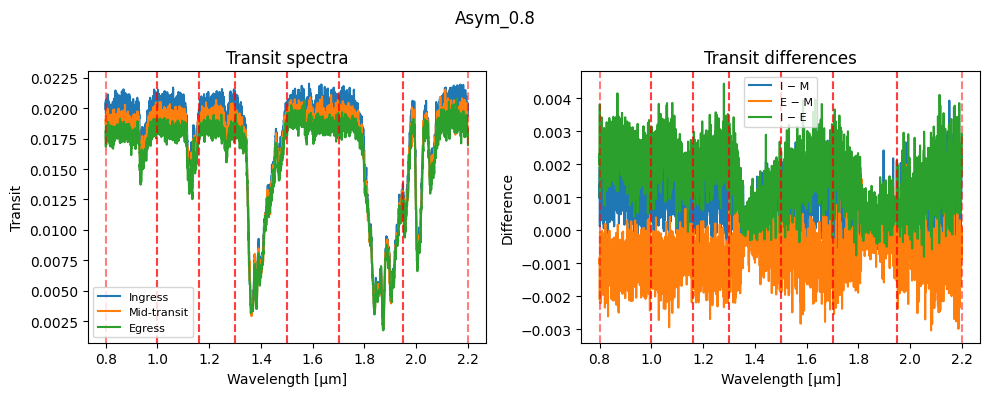

Regional metrics for Asym_0.8:


,Region,σ_det,σ_det_err,|I−E|,|I−E|_err,Z_D,ρ
0,0.8-1,4.228049,0.037157,0.002243,0.000020,5.937167,0.838773
1,1-1.16,3.819215,0.047766,0.002103,0.000026,4.349557,0.940208
2,1.16-1.3,3.492160,0.054305,0.002054,0.000032,6.196017,0.575473
3,1.3-1.5,1.956810,0.049055,0.001064,0.000024,3.296297,0.994146
4,1.5-1.7,2.696601,0.052715,0.001834,0.000036,5.816045,0.227110
5,1.7-1.95,1.666294,0.049736,0.001077,0.000027,3.142635,0.995070
6,1.95-2.2,1.786415,0.052865,0.001401,0.000038,4.020994,0.975722


Global metrics for Asym_0.8:


,Asymmetry,RMS,RMS_err,E,E_err
0,Asym_0.8,0.001919,0.000011,0.401763,0.002544


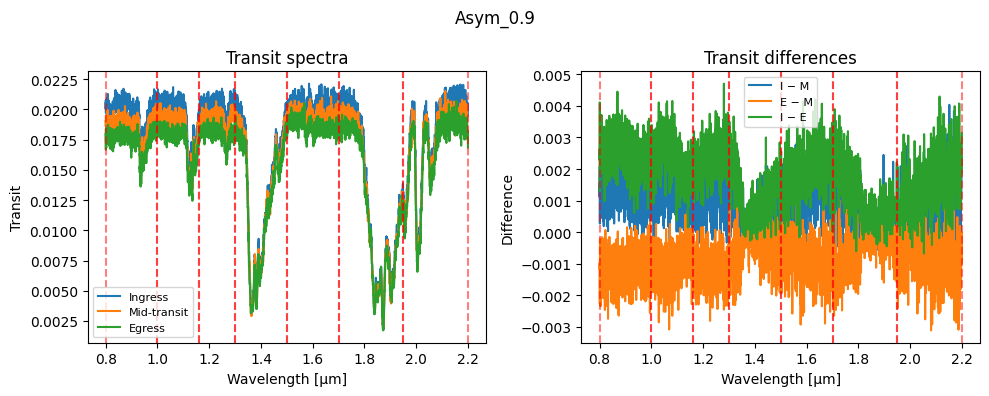

Regional metrics for Asym_0.9:


,Region,σ_det,σ_det_err,|I−E|,|I−E|_err,Z_D,ρ
0,0.8-1,4.740303,0.037158,0.002514,0.000020,5.937167,0.834249
1,1-1.16,4.282122,0.047766,0.002358,0.000026,4.349557,0.938677
2,1.16-1.3,3.914997,0.054305,0.002302,0.000032,6.196017,0.571404
3,1.3-1.5,2.191761,0.049055,0.001183,0.000025,3.296297,0.993896
4,1.5-1.7,3.021975,0.052715,0.002054,0.000036,5.816045,0.215588
5,1.7-1.95,1.866076,0.049736,0.001192,0.000028,3.142635,0.995014
6,1.95-2.2,1.999914,0.052865,0.001555,0.000039,4.020994,0.975470


Global metrics for Asym_0.9:


,Asymmetry,RMS,RMS_err,E,E_err
0,Asym_0.9,0.00213,0.000011,0.44985,0.002548


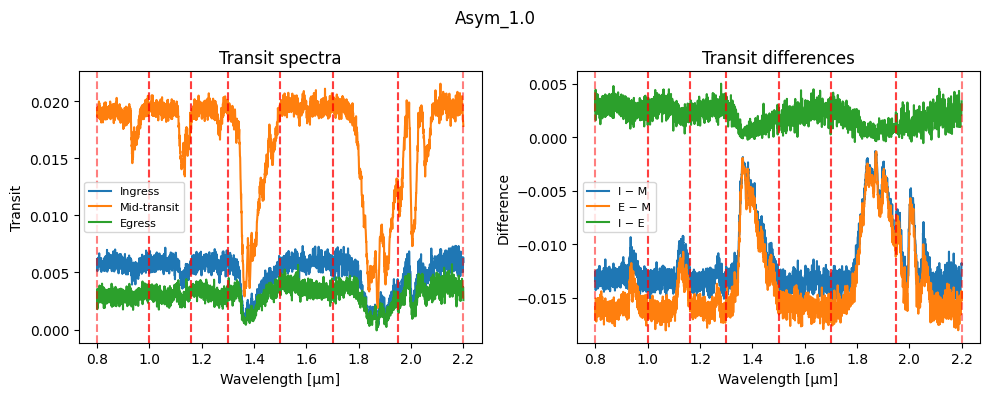

Regional metrics for Asym_1.0:


,Region,σ_det,σ_det_err,|I−E|,|I−E|_err,Z_D,ρ
0,0.8-1,5.209676,0.037158,0.002784,0.000020,5.937167,0.045351
1,1-1.16,4.706497,0.047766,0.002612,0.000026,4.349557,0.186366
2,1.16-1.3,4.303689,0.054304,0.002550,0.000032,6.196017,0.069065
3,1.3-1.5,2.403080,0.049054,0.001303,0.000025,3.296297,0.875783
4,1.5-1.7,3.320100,0.052715,0.002273,0.000036,5.816045,0.007058
5,1.7-1.95,2.047157,0.049736,0.001309,0.000028,3.142635,0.902729
6,1.95-2.2,2.197525,0.052865,0.001714,0.000039,4.020994,0.647106


Global metrics for Asym_1.0:


,Asymmetry,RMS,RMS_err,E,E_err
0,Asym_1.0,0.002342,0.000011,1.881222,0.011531


In [5]:
regions = [
    (0.80, 1),   # Rayleigh + optical continuum / H− slope
    (1, 1.16),   # continuum (reference baseline)
    (1.16, 1.30),   # weak H2O + continuum transition
    (1.30, 1.50),   # STRONG H2O band (main signal)
    (1.50, 1.70),   # H2O wing / opacity plateau
    (1.70, 1.95),   # second H2O band
    (1.95, 2.20)    # deep IR tail (temperature + opacity)
]
work_dir = os.getcwd()
results = []
def load_phase_data(folder):
    base = os.path.join(work_dir, folder)
    def load_one(phase):
        path = os.path.join(base, f"{phase}.txt")
        data = np.loadtxt(path)
        data = np.array(data)
        data = data[~np.isnan(data).any(axis=1)]
        return data
    return (load_one("ingress"), load_one("mid"), load_one("egress"))
def bin_spectrum(λ, f, σ, nbins=30):
    edges = np.linspace(λ.min(), λ.max(), nbins + 1)
    λ_bin = 0.5 * (edges[:-1] + edges[1:])
    f_bin = np.zeros(nbins)
    σ_bin = np.zeros(nbins)
    for i in range(nbins):
        m = (λ >= edges[i]) & (λ < edges[i+1])
        if np.any(m):
            w = 1 / σ[m]**2
            f_bin[i] = np.sum(f[m] * w) / np.sum(w)
            σ_bin[i] = np.sqrt(1 / np.sum(w))
        else:
            f_bin[i] = np.nan
            σ_bin[i] = np.nan
    return λ_bin, f_bin, σ_bin
def analiza(folder):
    ing, mid, egr = load_phase_data(folder)
    λ = ing[:,0]
    transit_ing = ing[:, -1]
    transit_mid = mid[:, -1]
    transit_egr = egr[:, -1]
    ni = ing[:,2]
    nm = mid[:,2]
    ne = egr[:,2]
    rng = np.random.default_rng(42)
    f_ing = transit_ing + rng.normal(0.0, ni)
    f_mid = transit_mid + rng.normal(0.0, nm)
    f_egr = transit_egr + rng.normal(0.0, ne)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    ax = axes[0]
    ax.plot(λ, f_ing, label="Ingress")
    ax.plot(λ, f_mid, label="Mid-transit")
    ax.plot(λ, f_egr, label="Egress")
    for r1, r2 in regions:
        ax.axvline(r1, linestyle='--', color='red', alpha=0.5)
        ax.axvline(r2, linestyle='--', color='red', alpha=0.5)
    ax.set_xlabel("Wavelength [μm]")
    ax.set_ylabel("Transit")
    ax.set_title("Transit spectra")
    ax.legend(fontsize=8)
    ax = axes[1]
    ax.plot(λ, f_ing - f_mid, label="I − M")
    ax.plot(λ, f_egr - f_mid, label="E − M")
    ax.plot(λ, f_ing - f_egr, label="I − E")
    for r1, r2 in regions:
        ax.axvline(r1, linestyle='--', color='red', alpha=0.5)
        ax.axvline(r2, linestyle='--', color='red', alpha=0.5)
    ax.set_xlabel("Wavelength [μm]")
    ax.set_ylabel("Difference")
    ax.set_title("Transit differences")
    ax.legend(fontsize=8)
    plt.suptitle(folder, fontsize=12)
    plt.tight_layout()
    plt.show()
    N_MC = 1000
    regional_rows = []
    mc_results = {r: {'σ_det': [], '|I−E|': [], 'Z_D': [], 'ρ': []} for r in range(len(regions))}
    for k in range(N_MC):
        mc_ing = transit_ing + rng.normal(0.0, ni)
        mc_mid = transit_mid + rng.normal(0.0, nm)
        mc_egr = transit_egr + rng.normal(0.0, ne)
        for r_idx, (r1, r2) in enumerate(regions):
            mask = (λ >= r1) & (λ <= r2)
            fi_reg = mc_ing[mask]
            fe_reg = mc_egr[mask]
            ni_reg = ni[mask]
            ne_reg = ne[mask]
            spec_diff = fi_reg - fe_reg
            σ_comb = np.sqrt(ni_reg**2 + ne_reg**2)
            σ_det = np.mean(spec_diff / σ_comb)
            mc_results[r_idx]['σ_det'].append(σ_det)
            mean_diff = np.mean(np.abs(spec_diff))
            mc_results[r_idx]['|I−E|'].append(mean_diff)
            if np.std(mc_mid[mask]) > 0:
                Z_D = (np.max(mc_mid[mask]) - np.min(mc_mid[mask])) / np.std(mc_mid[mask])
                mc_results[r_idx]['Z_D'].append(Z_D)
            if len(fi_reg) > 1 and np.std(fi_reg) > 0 and np.std(fe_reg) > 0:
                ρ = np.corrcoef(fi_reg, fe_reg)[0,1]
                mc_results[r_idx]['ρ'].append(ρ)
    for r_idx, (r1, r2) in enumerate(regions):
        σ_det_vals = np.array(mc_results[r_idx]['σ_det'])
        diff_vals = np.array(mc_results[r_idx]['|I−E|'])
        z_vals = np.array(mc_results[r_idx]['Z_D']) if mc_results[r_idx]['Z_D'] else np.array([np.nan])
        ρ_vals = np.array(mc_results[r_idx]['ρ']) if mc_results[r_idx]['ρ'] else np.array([np.nan])
        regional_rows.append({'Region': f"{r1}-{r2}", 'σ_det': np.mean(σ_det_vals), 'σ_det_err': np.std(σ_det_vals), '|I−E|': np.mean(diff_vals), 
                              '|I−E|_err': np.std(diff_vals), 'Z_D': np.nanmean(z_vals), 'ρ': np.nanmean(ρ_vals)})
    df_reg = pd.DataFrame(regional_rows)
    print(f"Regional metrics for {folder}:")
    display(df_reg)
    global_rms = []
    global_E = []
    for k in range(N_MC):
        mc_ing = transit_ing + rng.normal(0.0, ni)
        mc_egr = transit_egr + rng.normal(0.0, ne)
        spec_diff = mc_ing - mc_egr
        abs_diff = np.abs(spec_diff)
        rms = np.sqrt(np.mean(abs_diff**2))
        global_rms.append(rms)
        μ_i = np.mean(mc_ing)
        μ_e = np.mean(mc_egr)
        σ_i = np.std(mc_ing)
        σ_e = np.std(mc_egr)
        E = (μ_i - μ_e) / np.sqrt((σ_i**2 + σ_e**2) / 2)
        global_E.append(E)
    global_data = pd.DataFrame([{"Asymmetry": folder, "RMS": np.mean(global_rms), "RMS_err": np.std(global_rms), "E": np.mean(global_E),
                                  "E_err": np.std(global_E)}])
    print(f"Global metrics for {folder}:")
    display(global_data)
    return np.mean(global_rms), np.std(global_rms), np.mean(global_E), np.std(global_E)
asymmetry_levels = np.arange(0.1, 1.01, 0.1)
folders = [f"Asym_{a:.1f}" for a in asymmetry_levels]
for f in folders:
    result = analiza(f)
    results.append(result)

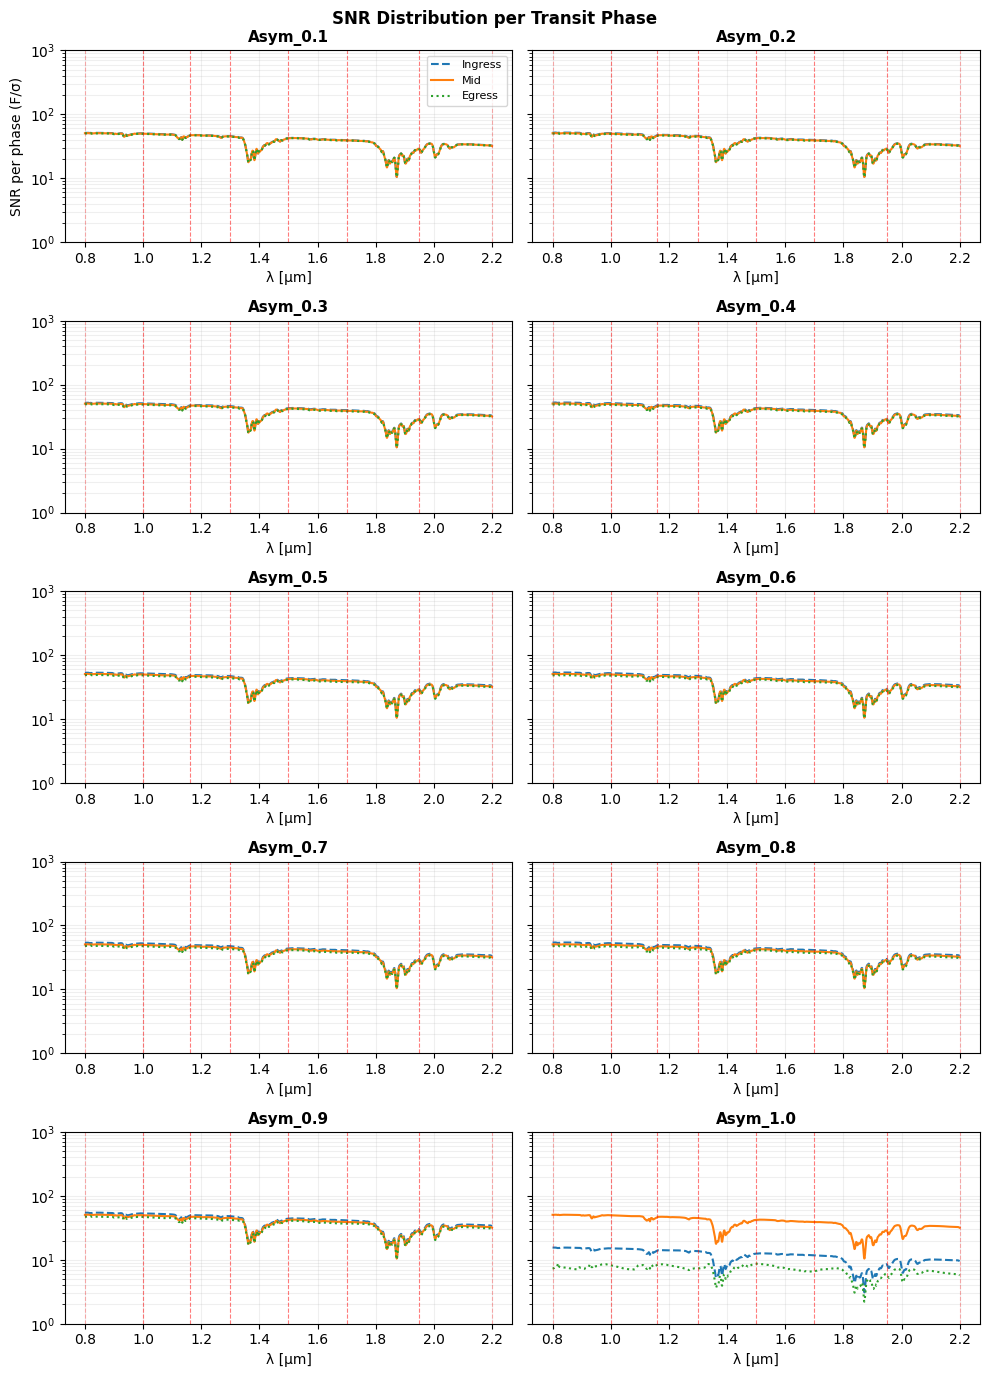

In [7]:
# SNR PER PHASE ANALYSIS - UPDATED FOR Asym_* FOLDERS
fig, axes = plt.subplots(5, 2, figsize=(10, 14), sharey=True)
axes = axes.flatten()
for i, folder in enumerate(folders):
    ax = axes[i]
    ing, mid, egr = load_phase_data(folder)
    λ = ing[:, 0]
    fi = ing[:, -1]
    fm = mid[:, -1]
    fe = egr[:, -1]
    ni = ing[:, 2]
    nm = mid[:, 2]
    ne = egr[:, 2]
    # stable SNR (no divide-by-zero crash)
    snr_ing = np.divide(fi, ni, out=np.zeros_like(fi), where=ni > 0)
    snr_mid = np.divide(fm, nm, out=np.zeros_like(fm), where=nm > 0)
    snr_egr = np.divide(fe, ne, out=np.zeros_like(fe), where=ne > 0)
    ax.plot(λ, snr_ing, linestyle='--', label="Ingress", linewidth=1.5)
    ax.plot(λ, snr_mid, linestyle='-', label="Mid", linewidth=1.5)
    ax.plot(λ, snr_egr, linestyle=':', label="Egress", linewidth=1.5)
    for r1, r2 in regions:
        ax.axvline(r1, linestyle='--', color='red', alpha=0.3, linewidth=0.8)
        ax.axvline(r2, linestyle='--', color='red', alpha=0.3, linewidth=0.8)
    ax.set_yscale('log')
    ax.set_ylim([1, 1000])
    ax.set_title(folder, fontsize=11, fontweight='bold')
    ax.set_xlabel("λ [μm]", fontsize=10)
    ax.grid(True, alpha=0.2, which='both')
axes[0].set_ylabel("SNR per phase (F/σ)", fontsize=10)
axes[0].legend(fontsize=8)
plt.suptitle("SNR Distribution per Transit Phase", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# ASYMMETRY LABELS
labels = folders
# numerical asymmetry axis
asymmetry_values = np.array([float(f.split("_")[1]) for f in folders])
# unpack results
rms_values = np.array([r[0] for r in results])
rms_errors = np.array([r[1] for r in results])
effect_values = np.array([r[2] for r in results])
effect_errors = np.array([r[3] for r in results])
# linear fits
z_rms = np.polyfit(asymmetry_values, rms_values, 1)
z_effect = np.polyfit(asymmetry_values, effect_values, 1)
# smooth fit curves
x_fit = np.linspace(asymmetry_values.min(), asymmetry_values.max(), 200)
rms_fit = np.polyval(z_rms, x_fit)
effect_fit = np.polyval(z_effect, x_fit)
# PRINT RESULTS
print("\nLinear trends (slope per asymmetry level):")
print(f"RMS slope:         {z_rms[0]:.3e}")
print(f"Effect size slope: {z_effect[0]:.3e}")
print("\nSummary of results:")
print("\nRMS (Root Mean Square Ingress−Egress difference):")
for i, label in enumerate(labels):
    print(f"{label:12s}: "    f"{rms_values[i]:.6e} ± {rms_errors[i]:.6e}")
print("\nEffect Size E (Cohen's d):")
for i, label in enumerate(labels):
    print(f"{label:12s}: " f"{effect_values[i]:+.6f} ± {effect_errors[i]:.6f}")


Linear trends (slope per asymmetry level):
RMS slope:         1.922e-03
Effect size slope: 1.243e+00

Summary of results:

RMS (Root Mean Square Ingress−Egress difference):
Asym_0.1    : 6.479337e-04 ± 8.839252e-06
Asym_0.2    : 7.700700e-04 ± 9.601260e-06
Asym_0.3    : 9.302448e-04 ± 1.011406e-05
Asym_0.4    : 1.111385e-03 ± 1.042213e-05
Asym_0.5    : 1.304587e-03 ± 1.060854e-05
Asym_0.6    : 1.505149e-03 ± 1.072556e-05
Asym_0.7    : 1.710455e-03 ± 1.080218e-05
Asym_0.8    : 1.918976e-03 ± 1.085419e-05
Asym_0.9    : 2.129765e-03 ± 1.089073e-05
Asym_1.0    : 2.342100e-03 ± 1.099798e-05

Effect Size E (Cohen's d):
Asym_0.1    : +0.056864 ± 0.002528
Asym_0.2    : +0.108343 ± 0.002528
Asym_0.3    : +0.158290 ± 0.002529
Asym_0.4    : +0.207563 ± 0.002531
Asym_0.5    : +0.256453 ± 0.002533
Asym_0.6    : +0.305084 ± 0.002536
Asym_0.7    : +0.353512 ± 0.002540
Asym_0.8    : +0.401763 ± 0.002544
Asym_0.9    : +0.449850 ± 0.002548
Asym_1.0    : +1.881222 ± 0.011531



Linear trends (slope per asymmetry level):
RMS:         1.922e-03
Effect size: 1.243e+00


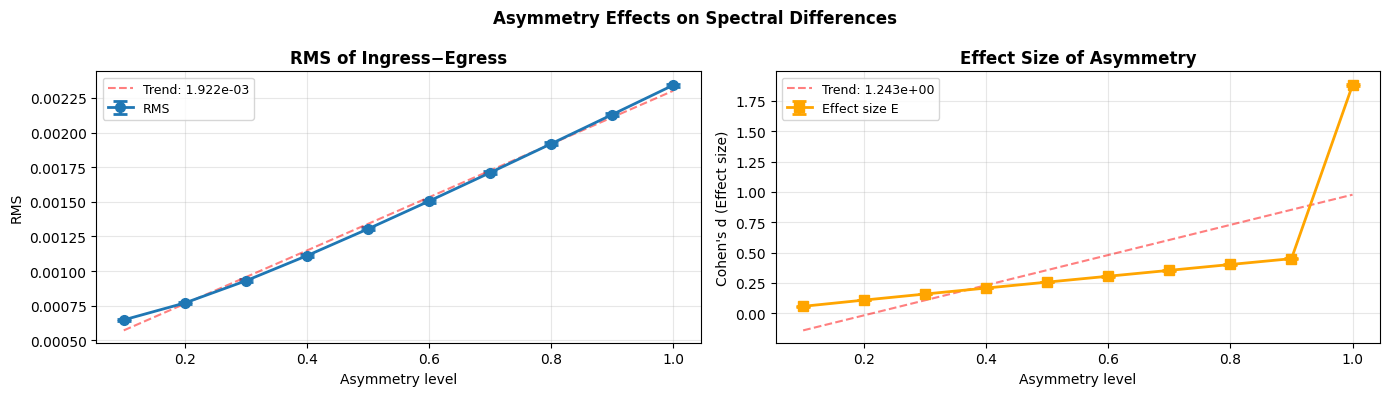

In [10]:
# AUTOMATIC ASYMMETRY SUMMARY (UPDATED FOR Asym_*)
labels = folders
# numerical asymmetry values extracted from folder names
x = np.array([float(f.split("_")[1]) for f in folders])
rms_values = np.array([r[0] for r in results])
rms_errors = np.array([r[1] for r in results])
effect_values = np.array([r[2] for r in results])
effect_errors = np.array([r[3] for r in results])
# linear fits
z_rms = np.polyfit(x, rms_values, 1)
z_effect = np.polyfit(x, effect_values, 1)
x_fit = np.linspace(x.min(), x.max(), 200)
rms_fit = np.polyval(z_rms, x_fit)
effect_fit = np.polyval(z_effect, x_fit)
print("\nLinear trends (slope per asymmetry level):")
print(f"RMS:         {z_rms[0]:.3e}")
print(f"Effect size: {z_effect[0]:.3e}")
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
# RMS panel
ax = axes[0]
ax.errorbar(x, rms_values, yerr=rms_errors, fmt='o-', capsize=5, capthick=2, markersize=7, linewidth=2, label='RMS')
ax.plot(x_fit, rms_fit, '--', color='red', alpha=0.5, label=f'Trend: {z_rms[0]:.3e}')
ax.set_xlabel("Asymmetry level", fontsize=10)
ax.set_ylabel("RMS", fontsize=10)
ax.set_title("RMS of Ingress−Egress", fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)
# EFFECT SIZE PANEL
ax = axes[1]
ax.errorbar(x, effect_values, yerr=effect_errors, fmt='s-', capsize=5, capthick=2, markersize=7, linewidth=2, color='orange', label='Effect size E')
ax.plot(x_fit, effect_fit, '--', color='red', alpha=0.5, label=f'Trend: {z_effect[0]:.3e}')
ax.set_xlabel("Asymmetry level", fontsize=10)
ax.set_ylabel("Cohen's d (Effect size)", fontsize=10)
ax.set_title("Effect Size of Asymmetry", fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)
plt.suptitle("Asymmetry Effects on Spectral Differences", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### INTERPRETATION:

The asymmetry sequence was generated through linear interpolation between the reference symmetric model and the extreme ultra-asymmetric configuration.
The left panel shows that the RMS of ingress−egress spectral differences follows an almost perfectly linear dependence on the imposed asymmetry level.

However, the Cohen’s d metric behaves differently. While the trend remains approximately linear between asymmetry levels 0.1–0.9, a pronounced increase appears between 0.9 and 1.0. This suggests that, near the extreme atmospheric contrast regime, the statistical distinguishability between ingress and egress spectra becomes significantly enhanced.

Rather than indicating a purely linear observational response, this behaviour may point to the onset of amplified sensitivity to atmospheric asymmetry in the most extreme configurations. In practical terms, the ingress and egress spectra become increasingly separable as independent atmospheric states.

Such behaviour is qualitatively consistent with recent JWST-era studies of limb asymmetries and multidimensional transmission spectroscopy, where east–west temperature gradients, cloud inhomogeneities, and terminator structure can produce detectable non-linear observational signatures in transmission spectra.

For further discussion of nonlinear atmospheric responses and heterogeneous terminator effects in transmission spectroscopy, see also [Arnold et al. (2025)](https://arxiv.org/pdf/2504.14060), [MacDonald et al. (2021)](https://arxiv.org/pdf/2111.05862), and [Caldas et al. (2019)](https://arxiv.org/pdf/1901.09932).

In [16]:
# NOISE DIAGNOSTICS FOR ALL ASYMMETRIES
phases = ['ingress', 'mid', 'egress']
for folder in folders:
    print(f"{folder}")
    for phase in phases:
        print(f"\nNoise diagnostics for {phase.capitalize()}")
        data = np.loadtxt(os.path.join(folder, f"{phase}.txt"), comments="#")
        λ = data[:, 0]
        total_flux = data[:, -1]
        noise = data[:, 2]
        print(f"\nFlux statistics ({phase.capitalize()}):")
        print(f"  Mean value: {np.mean(total_flux):.6e}")
        print(f"  Min: {np.min(total_flux):.6e}, " f"Max: {np.max(total_flux):.6e}")
        print(f"\nNoise (σ) statistics:")
        print(f"  Mean σ: {np.mean(noise):.6e}")
        print(f"  Min σ: {np.min(noise):.6e}, " f"Max σ: {np.max(noise):.6e}")
        snr = total_flux / noise
        print(f"\nSNR (Flux/σ) statistics:")
        print(f"  Mean SNR: {np.mean(snr):.2f}")
        print(f"  Min SNR: {np.min(snr):.2f}, " f"Max SNR: {np.max(snr):.2f}")
        print(f"\nNoise ratio with respect to Flux:")
        print(f"  σ/F ratio: " f"{np.mean(noise/total_flux):.4f} " f"(average {100*np.mean(noise/total_flux):.2f}%)")
        region_data = []
        for r1, r2 in regions:
            mask = (λ >= r1) & (λ <= r2)
            region_data.append({'Region [μm]': f"{r1}-{r2}", '<Flux>': f"{np.mean(total_flux[mask]):.6e}", '<σ>': f"{np.mean(noise[mask]):.6e}", 
                                '<SNR>': f"{np.mean(snr[mask]):6.2f}"})
        df_regions = pd.DataFrame(region_data)
        print(f"\nNoise by spectral regions for {phase}:")
        display(df_regions)

Asym_0.1

Noise diagnostics for Ingress

Flux statistics (Ingress):
  Mean value: 1.705596e-02
  Min: 1.972520e-03, Max: 2.002780e-02

Noise (σ) statistics:
  Mean σ: 4.140634e-04
  Min σ: 1.846540e-04, Max σ: 5.995350e-04

SNR (Flux/σ) statistics:
  Mean SNR: 41.05
  Min SNR: 10.50, Max SNR: 51.35

Noise ratio with respect to Flux:
  σ/F ratio: 0.0262 (average 2.62%)

Noise by spectral regions for ingress:


,Region [μm],<Flux>,<σ>,<SNR>
0,0.8-1,1.878337e-02,3.746144e-04,50.11
1,1-1.16,1.849301e-02,3.876710e-04,47.61
2,1.16-1.3,1.925130e-02,4.154788e-04,46.34
3,1.3-1.5,1.310949e-02,3.547375e-04,35.22
4,1.5-1.7,1.965989e-02,4.794351e-04,41.03
5,1.7-1.95,1.253110e-02,4.038702e-04,29.00
6,1.95-2.2,1.715845e-02,5.325348e-04,31.85



Noise diagnostics for Mid

Flux statistics (Mid):
  Mean value: 1.691403e-02
  Min: 1.960180e-03, Max: 1.988500e-02

Noise (σ) statistics:
  Mean σ: 4.140967e-04
  Min σ: 1.846650e-04, Max σ: 5.995810e-04

SNR (Flux/σ) statistics:
  Mean SNR: 40.70
  Min SNR: 10.43, Max SNR: 50.84

Noise ratio with respect to Flux:
  σ/F ratio: 0.0265 (average 2.65%)

Noise by spectral regions for mid:


,Region [μm],<Flux>,<σ>,<SNR>
0,0.8-1,1.860241e-02,3.746503e-04,49.62
1,1-1.16,1.832345e-02,3.877067e-04,47.17
2,1.16-1.3,1.908456e-02,4.155153e-04,45.93
3,1.3-1.5,1.301901e-02,3.547617e-04,34.97
4,1.5-1.7,1.950696e-02,4.794728e-04,40.71
5,1.7-1.95,1.244164e-02,4.038976e-04,28.79
6,1.95-2.2,1.703674e-02,5.325704e-04,31.62



Noise diagnostics for Egress

Flux statistics (Egress):
  Mean value: 1.681449e-02
  Min: 1.952510e-03, Max: 1.978910e-02

Noise (σ) statistics:
  Mean σ: 4.141200e-04
  Min σ: 1.846730e-04, Max σ: 5.996130e-04

SNR (Flux/σ) statistics:
  Mean SNR: 40.46
  Min SNR: 10.39, Max SNR: 50.47

Noise ratio with respect to Flux:
  σ/F ratio: 0.0266 (average 2.66%)

Noise by spectral regions for egress:


...

,Region [μm],<Flux>,<σ>,<SNR>
0,0.8-1,5.709159e-03,3.771904e-04,15.13
1,1-1.16,5.604602e-03,3.903400e-04,14.33
2,1.16-1.3,5.812730e-03,4.183476e-04,13.89
3,1.3-1.5,3.901930e-03,3.572174e-04,10.40
4,1.5-1.7,5.893851e-03,4.827562e-04,12.21
5,1.7-1.95,3.735739e-03,4.066036e-04,8.58
6,1.95-2.2,5.107470e-03,5.361557e-04,9.41



Noise diagnostics for Mid

Flux statistics (Mid):
  Mean value: 1.691403e-02
  Min: 1.960180e-03, Max: 1.988500e-02

Noise (σ) statistics:
  Mean σ: 4.140967e-04
  Min σ: 1.846650e-04, Max σ: 5.995810e-04

SNR (Flux/σ) statistics:
  Mean SNR: 40.70
  Min SNR: 10.43, Max SNR: 50.84

Noise ratio with respect to Flux:
  σ/F ratio: 0.0265 (average 2.65%)

Noise by spectral regions for mid:


,Region [μm],<Flux>,<σ>,<SNR>
0,0.8-1,1.860241e-02,3.746503e-04,49.62
1,1-1.16,1.832345e-02,3.877067e-04,47.17
2,1.16-1.3,1.908456e-02,4.155153e-04,45.93
3,1.3-1.5,1.301901e-02,3.547617e-04,34.97
4,1.5-1.7,1.950696e-02,4.794728e-04,40.71
5,1.7-1.95,1.244164e-02,4.038976e-04,28.79
6,1.95-2.2,1.703674e-02,5.325704e-04,31.62



Noise diagnostics for Egress

Flux statistics (Egress):
  Mean value: 3.006287e-03
  Min: 4.183370e-04, Max: 4.030080e-03

Noise (σ) statistics:
  Mean σ: 4.174329e-04
  Min σ: 1.860550e-04, Max σ: 6.042910e-04

SNR (Flux/σ) statistics:
  Mean SNR: 7.15
  Min SNR: 2.21, Max SNR: 8.82

Noise ratio with respect to Flux:
  σ/F ratio: 0.1454 (average 14.54%)

Noise by spectral regions for egress:


,Region [μm],<Flux>,<σ>,<SNR>
0,0.8-1,2.924747e-03,3.777485e-04,7.74
1,1-1.16,2.992675e-03,3.909038e-04,7.66
2,1.16-1.3,3.262867e-03,4.189294e-04,7.79
3,1.3-1.5,2.606901e-03,3.575863e-04,6.99
4,1.5-1.7,3.620054e-03,4.833578e-04,7.51
5,1.7-1.95,2.450145e-03,4.070370e-04,5.68
6,1.95-2.2,3.403091e-03,5.367077e-04,6.29


### Note on noise model

Noise values (σ) in column 3 of the PSG-generated `.txt` files correspond to the total simulated observational uncertainty provided by PSG. These uncertainties include instrumental and detector contributions together with photon/statistical noise components from the adopted observing configuration.

The resulting σ values are wavelength-dependent and are not strictly constant across the spectrum. In this work, they are used directly as provided by PSG, without introducing additional wavelength-dependent re-scaling or empirical JWST systematics corrections.

The adopted PSG noise model should therefore be interpreted as an idealized simulation-level approximation of JWST transit spectroscopy uncertainties, rather than a complete end-to-end detector systematics treatment.


In [14]:
# DETECTABILITY ANALYSIS
print("Detectability analysis of " "Ingress-Egress difference " "for all asymmetry levels:")
for folder in folders:
    print(f"\n{folder}")
    ing = np.loadtxt(os.path.join(folder, "ingress.txt"), comments="#")
    egr = np.loadtxt(os.path.join(folder, "egress.txt"), comments="#")
    λ = ing[:, 0]
    f_ing = ing[:, -1]
    f_egr = egr[:, -1]
    ni = ing[:, 2]
    ne = egr[:, 2]
    σ_comb = np.sqrt(ni**2 + ne**2)
    diff_raw = f_ing - f_egr
    snr_diff = diff_raw / σ_comb
    print("\nRaw difference (Ingress - Egress):")
    print(f"  Mean value: {np.mean(diff_raw):.6e}")
    print(f"  Std dev: {np.std(diff_raw):.6e}")
    print(f"  Max |difference|: " f"{np.max(np.abs(diff_raw)):.6e}")
    print("\nSNR of detection (difference / combined σ):")
    print(f"  Mean SNR: {np.mean(snr_diff):.4f}")
    print(f"  Max SNR: {np.max(snr_diff):.4f}")
    print(f"  Min SNR: {np.min(snr_diff):.4f}")
    print("\nBy spectral regions:")
    region_data = []
    for r1, r2 in regions:
        mask = (λ >= r1) & (λ <= r2)
        avg_snr_region = np.mean(snr_diff[mask])
        max_snr_region = np.max(snr_diff[mask])
        region_data.append({'Region [μm]': f"{r1}-{r2}", '<SNR>': f"{avg_snr_region:.3f}", 'Max SNR': f"{max_snr_region:.3f}"})
        print(f"  {r1}-{r2} μm: " f"<SNR> = {avg_snr_region:.3f}, " f"max = {max_snr_region:.3f}")
    df_regions = pd.DataFrame(region_data)
    print("\nNoise by spectral regions:")
    display(df_regions)

Detectability analysis of Ingress-Egress difference for all asymmetry levels:

Asym_0.1

Raw difference (Ingress - Egress):
  Mean value: 2.414730e-04
  Std dev: 8.471645e-05
  Max |difference|: 3.544000e-04

SNR of detection (difference / combined σ):
  Mean SNR: 0.4133
  Max SNR: 0.6600
  Min SNR: 0.0753

By spectral regions:
  0.8-1 μm: <SNR> = 0.588, max = 0.660
  1-1.16 μm: <SNR> = 0.532, max = 0.606
  1.16-1.3 μm: <SNR> = 0.488, max = 0.516
  1.3-1.5 μm: <SNR> = 0.282, max = 0.501
  1.5-1.7 μm: <SNR> = 0.382, max = 0.426
  1.7-1.95 μm: <SNR> = 0.240, max = 0.411
  1.95-2.2 μm: <SNR> = 0.260, max = 0.317

Noise by spectral regions:


,Region [μm],<SNR>,Max SNR
0,0.8-1,0.588,0.660
1,1-1.16,0.532,0.606
2,1.16-1.3,0.488,0.516
3,1.3-1.5,0.282,0.501
4,1.5-1.7,0.382,0.426
5,1.7-1.95,0.240,0.411
6,1.95-2.2,0.260,0.317



Asym_0.2

Raw difference (Ingress - Egress):
  Mean value: 4.603368e-04
  Std dev: 1.639178e-04
  Max |difference|: 6.816000e-04

SNR of detection (difference / combined σ):
  Mean SNR: 0.7882
  Max SNR: 1.2694
  Min SNR: 0.1413

By spectral regions:
  0.8-1 μm: <SNR> = 1.127, max = 1.269
  1-1.16 μm: <SNR> = 1.018, max = 1.166
  1.16-1.3 μm: <SNR> = 0.933, max = 0.989
  1.3-1.5 μm: <SNR> = 0.533, max = 0.960
  1.5-1.7 μm: <SNR> = 0.726, max = 0.815
  1.7-1.95 μm: <SNR> = 0.453, max = 0.785
  1.95-2.2 μm: <SNR> = 0.489, max = 0.601

Noise by spectral regions:


,Region [μm],<SNR>,Max SNR
0,0.8-1,1.127,1.269
1,1-1.16,1.018,1.166
2,1.16-1.3,0.933,0.989
3,1.3-1.5,0.533,0.960
4,1.5-1.7,0.726,0.815
5,1.7-1.95,0.453,0.785
6,1.95-2.2,0.489,0.601



Asym_0.3

Raw difference (Ingress - Egress):
  Mean value: 6.729421e-04
  Std dev: 2.416030e-04
  Max |difference|: 1.001100e-03

SNR of detection (difference / combined σ):
  Mean SNR: 1.1524
  Max SNR: 1.8644
  Min SNR: 0.2046

By spectral regions:
  0.8-1 μm: <SNR> = 1.652, max = 1.864
  1-1.16 μm: <SNR> = 1.492, max = 1.713
  1.16-1.3 μm: <SNR> = 1.366, max = 1.451
  1.3-1.5 μm: <SNR> = 0.776, max = 1.408
  1.5-1.7 μm: <SNR> = 1.061, max = 1.194
  1.7-1.95 μm: <SNR> = 0.659, max = 1.149
  1.95-2.2 μm: <SNR> = 0.711, max = 0.877

Noise by spectral regions:


...

,Region [μm],<SNR>,Max SNR
0,0.8-1,4.228,4.790
1,1-1.16,3.820,4.404
2,1.16-1.3,3.492,3.720
3,1.3-1.5,1.959,3.608
4,1.5-1.7,2.698,3.057
5,1.7-1.95,1.666,2.937
6,1.95-2.2,1.787,2.221



Asym_0.9

Raw difference (Ingress - Egress):
  Mean value: 1.921149e-03
  Std dev: 7.010553e-04
  Max |difference|: 2.884500e-03

SNR of detection (difference / combined σ):
  Mean SNR: 3.2908
  Max SNR: 5.3717
  Min SNR: 0.5733

By spectral regions:
  0.8-1 μm: <SNR> = 4.740, max = 5.372
  1-1.16 μm: <SNR> = 4.283, max = 4.939
  1.16-1.3 μm: <SNR> = 3.915, max = 4.171
  1.3-1.5 μm: <SNR> = 2.194, max = 4.046
  1.5-1.7 μm: <SNR> = 3.023, max = 3.427
  1.7-1.95 μm: <SNR> = 1.866, max = 3.292
  1.95-2.2 μm: <SNR> = 2.001, max = 2.487

Noise by spectral regions:


,Region [μm],<SNR>,Max SNR
0,0.8-1,4.740,5.372
1,1-1.16,4.283,4.939
2,1.16-1.3,3.915,4.171
3,1.3-1.5,2.194,4.046
4,1.5-1.7,3.023,3.427
5,1.7-1.95,1.866,3.292
6,1.95-2.2,2.001,2.487



Asym_1.0

Raw difference (Ingress - Egress):
  Mean value: 2.126516e-03
  Std dev: 7.775178e-04
  Max |difference|: 3.196020e-03

SNR of detection (difference / combined σ):
  Mean SNR: 3.6152
  Max SNR: 5.9074
  Min SNR: 0.6186

By spectral regions:
  0.8-1 μm: <SNR> = 5.210, max = 5.907
  1-1.16 μm: <SNR> = 4.707, max = 5.432
  1.16-1.3 μm: <SNR> = 4.304, max = 4.589
  1.3-1.5 μm: <SNR> = 2.406, max = 4.449
  1.5-1.7 μm: <SNR> = 3.321, max = 3.765
  1.7-1.95 μm: <SNR> = 2.047, max = 3.615
  1.95-2.2 μm: <SNR> = 2.198, max = 2.732

Noise by spectral regions:


,Region [μm],<SNR>,Max SNR
0,0.8-1,5.210,5.907
1,1-1.16,4.707,5.432
2,1.16-1.3,4.304,4.589
3,1.3-1.5,2.406,4.449
4,1.5-1.7,3.321,3.765
5,1.7-1.95,2.047,3.615
6,1.95-2.2,2.198,2.732


## Interpretation: Why optical region detects asymmetry better than H₂O band?

The optical region (0.8–1.0 μm) consistently shows the highest σ_det values across all asymmetry configurations, while the strong H₂O band (1.3–1.5 μm) exhibits lower detection significance. This is not accidental, but reflects the physical source of terminator asymmetry in WASP-17b.

**Rayleigh scattering and continuum dominance:** Terminator asymmetry in WASP-17b is primarily driven by temperature differences across ingress and egress limbs, which affect the continuum flux and Rayleigh scattering. Rayleigh scattering cross-section scales as λ⁻⁴, making it much stronger in the optical/blue spectral region than in the infrared. Consequently, the continuum and scattering contributions—which carry the asymmetry signature—are more pronounced at shorter wavelengths.

**H₂O uniformity across the terminator:** The water band (1.3–1.5 μm), by contrast, represents molecular absorption that is relatively uniform on both sides of the terminator. The column of H₂O gas is determined largely by global abundance and pressure structure, which do not vary dramatically from ingress to egress in simplified models. This uniformity suppresses the differential signal in H₂O bands, reducing their sensitivity to asymmetry even though they are spectroscopically strong.

**Consistency with GCM predictions:** This behavior is consistent with general circulation models (GCMs) of hot-Jupiter atmospheres, where wind patterns and circulation asymmetries manifest primarily in temperature structure and opacity (scattering), rather than molecular mixing ratios. The asymmetry thus imprints most clearly on continuum and Rayleigh-scattered light, making the optical region the most sensitive probe.

**Implication for JWST observations:** This prediction suggests that optical and near-infrared observations (e.g., JWST/NIRISS SOSS) are better suited for detecting terminator asymmetry in WASP-17b than narrowband filters or spectroscopy in strong H₂O absorption features. This aligns with the priority of optical spectroscopy in recent JWST-TST programs targeting terminator physics.

Cell below serves a purpose of showing what were the parametres whose values where varied for this research analysis.

In [18]:
# CFG PARAMETER EXTRACTION
folders = [f"Asym_{i/10:.1f}" for i in range(1, 11)]
params = ["ATMOSPHERE-CLOUDFRACTION", "ATMOSPHERE-AABUN", "ATMOSPHERE-ASIZE", "ATMOSPHERE-TEMPERATURE"]
rows = []
for folder in folders:
    for phase in ["ingress", "mid", "egress"]:
        # SPECIAL CASE FOR Asym_1.0
        if folder == "Asym_1.0":
            mapping = {"ingress": "wasp17b_transit_ingress_ultra_hazy_cold.cfg","mid": "wasp17b_transit_mid_ultra_reference.cfg",
                "egress": "wasp17b_transit_egress_ultra_clear_hot.cfg"}
            cfg_path = os.path.join(folder, mapping[phase])
        else:
            cfg_path = os.path.join(folder, f"{phase}.cfg")
        if not os.path.exists(cfg_path):
            print(f"Missing: {cfg_path}")
            continue
        values = {"Asymmetry": folder, "Phase": phase}
        with open(cfg_path, "r", encoding="utf-8") as f:
            lines = f.readlines()
        for p in params:
            for line in lines:
                if f"<{p}>" in line:
                    values[p] = line.split(">")[1].strip()
        rows.append(values)
df_cfg = pd.DataFrame(rows)
display(df_cfg)
df_cfg.to_csv("wasp17b_asymmetry_parameters.csv", index=False)

,Asymmetry,Phase,ATMOSPHERE-CLOUDFRACTION,ATMOSPHERE-AABUN,ATMOSPHERE-ASIZE,ATMOSPHERE-TEMPERATURE
0,Asym_0.1,ingress,0.55,0.17200000000000001,1.0,1696.7620000000002
1,Asym_0.1,mid,0.5,0.08,1.0,1724.18
2,Asym_0.1,egress,0.45,0.07200000000000001,1.0,1756.7620000000002
3,Asym_0.2,ingress,0.6,0.264,1.0,1669.344
4,Asym_0.2,mid,0.5,0.08,1.0,1724.18
5,Asym_0.2,egress,0.4,0.064,1.0,1789.344
6,Asym_0.3,ingress,0.65,0.3560000000000001,1.0,1641.926
7,Asym_0.3,mid,0.5,0.08,1.0,1724.18
8,Asym_0.3,egress,0.35,0.055999999999999994,1.0,1821.9260000000002
9,Asym_0.4,ingress,0.7,0.44800000000000006,1.0,1614.508


# References and original contributions

This analysis combines established transmission spectroscopy methods with a phase-resolved asymmetry study tailored for the WASP-17b model set.

## WASP-17b literature and directly related studies

- _[JWST-TST DREAMS: A Precise Water Abundance for Hot Jupiter WASP-17b from the NIRISS SOSS Transmission Spectrum — Lin et al. (2024)](https://iopscience.iop.org/article/10.3847/1538-3881/ad9688/pdf)_ - The paper on which are made the most of the corelations, the rest is additional literature and reference on topic. Important note - our spectra are generated as $F_p/F_*$ (Radiance unit: Contrast [radiance ratio w.r.t. parent star]) instead of Transit depth as $(R_p/R_s)^2$ or in ppms, or scaled to percentage.

- _[A Comprehensive Analysis of WASP-17b's Transmission Spectrum from Space-Based Observations — Alderson et al. (2022)](https://arxiv.org/pdf/2203.02434)_ – comprehensive HST + Spitzer transmission-spectrum analysis of WASP-17b, including atmospheric retrievals, H2O and CO2 detections, cloud interpretation, and JWST relevance.

- _[JWST-TST DREAMS: Quartz Clouds in the Atmosphere of WASP-17b — Grant et al. (2023)](https://arxiv.org/pdf/2310.08637)_ – JWST/MIRI transmission spectroscopy of WASP-17b with quartz-cloud interpretation and aerosol analysis directly relevant to cloud asymmetry studies.

- _[The atmosphere of WASP-17b: Optical high-resolution transmission spectroscopy — Khalafinejad et al. (2018)](https://arxiv.org/pdf/1807.10621)_ – optical transmission spectroscopy of WASP-17b and sodium detection analysis using high-resolution spectra.



## Terminator asymmetry and phase-dependent atmosphere studies

- _[Transmission strings: a technique for spatially mapping exoplanet atmospheres around their terminators — Grant & Wakeford (2023)](https://academic.oup.com/mnras/article/519/4/5114/6889522)_ – spatially resolved transmission-spectroscopy framework and terminator asymmetry methodology.

- _[Spatially resolving the terminator: variation of Fe, temperature, and winds in WASP-76 b across planetary limbs and orbital phase — Gandhi et al. (2022)](https://academic.oup.com/mnras/article-lookup/doi/10.1093/mnras/stac1744)_ – ingress/egress-resolved atmospheric asymmetry analysis and limb-dependent atmospheric structure.

- _[Inhomogeneous terminators on the exoplanet WASP-39 b — Espinoza et al. (2024)](https://doi.org/10.1038/s41586-024-07768-4)_ – JWST observational evidence for non-uniform terminator structure and asymmetric atmospheric properties.

## Statistical and spectral-analysis methodology

- _[A continuum from clear to cloudy hot-Jupiter exoplanets without primordial water depletion - Sing et al. (2016)](https://sci-hub.box/10.1038/nature16068)_ – comparative hot-Jupiter transmission spectra, cloud classification, and wavelength-region interpretation.

- _[A PRECISE WATER ABUNDANCE MEASUREMENT FOR THE HOT JUPITER WASP-43b - Kreidberg et al. (2014)](https://sci-hub.box/10.1038/nature12988)_ – HST/WFC3 water-band detection and cloud-opacity constraints in transmission spectroscopy.

- _[SPITZER TRANSITS OF THE SUPER-EARTH GJ1214B AND IMPLICATIONS FOR ITS ATMOSPHERE - Benneke & Seager et al. (2013)](https://arxiv.org/pdf/1301.6763)_ – atmospheric retrieval statistics, degeneracies, and significance interpretation in exoplanet spectroscopy.

- _[HOW TO DISTINGUISH BETWEEN CLOUDY MINI-NEPTUNES AND WATER/VOLATILE-DOMINATED SUPER-EARTHS - Benneke & Seager (2013)](https://iopscience.iop.org/article/10.1088/0004-637X/778/2/153/pdf)_ – Bayesian atmospheric retrieval and spectral-detection methodology.

## Non-linear and heterogeneous atmospheric effects

- _[Out on a Limb: The Signatures of East-West Asymmetries in Transmission Spectra from General Circulation Models - Arnold et al. (2025)](https://arxiv.org/pdf/2504.14060)_ – discussion of complex atmospheric structure, multidimensional retrieval behaviour, and non-linear spectral responses in heterogeneous atmospheres.

- _[TRIDENT: A Rapid 3D Radiative Transfer Model for Exoplanet Transmission Spectra - MacDonald & Lewis (2021)](https://arxiv.org/pdf/2111.05862)_ – modelling framework for spatially varying atmospheric properties and asymmetric transmission spectra.

- _[Effects of a fully 3D atmospheric structure on exoplanet transmission spectra: retrieval biases due to day-night temperature gradients - Caldas et al. (2019)](https://arxiv.org/pdf/1901.09932)_ – analysis of how heterogeneous terminator structure and opacity variations affect observed transmission spectra.
## Relation to this notebook

The red dashed spectral boundaries correspond to physically motivated wavelength regions commonly used in hot-Jupiter transmission spectroscopy:
- optical / Rayleigh + H− slope region,
- continuum baseline,
- weak H2O transition region,
- strong H2O band,
- H2O wing / opacity plateau,
- second H2O band,
- deep IR tail.

The ingress / mid-transit / egress comparison follows the general philosophy of spatially resolved and phase-dependent transmission spectroscopy studies.

Regional detection estimates ($σ_{det}$), SNR diagnostics, Monte Carlo realizations, and regional correlation analysis were adapted for this notebook in order to compare different levels of asymmetry configurations consistently within a unified JWST-like simulation framework.

Novel notebook-specific contributions include:
- Monte Carlo evaluation of regional $σ_{det}$ values using noisy PSG realizations;
- consolidated ingress / mid / egress comparative diagnostics;
- physically motivated wavelength-region segmentation applied uniformly across asymmetry regimes;
- region-by-region asymmetry tracking using RMS, correlation ($ρ$), detectability, and spectral-difference metrics.